# Neural ODEs vs. LSTMs: Learning Dynamics

**Project Context:**
I did not know what PINN is. Just that i knew something existed. While studying for this Assignment, I came across and studied it. I did not know what Neural ODE is. I tried to read paper. It was time consuming. Studied from AI.
The context of the project is to detemine the outcome of a ODE using a neural network. before working, I created a sample dataset using scipy for the purpose of this project. I wanted to Try by using the physioNet ICU Dataset, but, knew, i can work on something like this, when i learn about neural ODE and what it is and how to implement them. For my learning purpose, I have used the simple damped pendulum equation.
I have tried to work with Neural ode using ODEINT and also, the LSTMs.

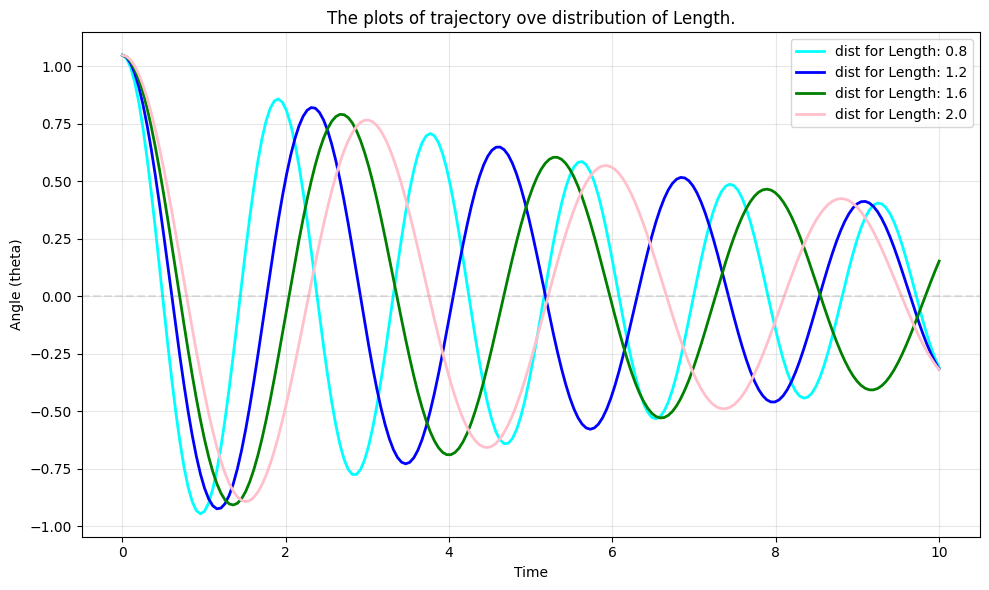

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def damp_pendulum(state, t, b, g, L):  # current_state, time, damp_coeff, g, Length_of_pendulum
  theta, omega = state
  dtheta_dt = omega
  domega_dt = -(g / L) * np.sin(theta) - b * omega
  return [dtheta_dt, domega_dt]

t_list = np.linspace(0, 10, 200)
initial_state = [np.pi / 3, 0.]
g = 9.81

lengths = [0.8, 1.2, 1.6, 2.]
colors = ['cyan', 'blue', 'green', 'pink']
dataset = []

plt.figure(figsize=(10, 6))

for L, color in zip(lengths, colors):
  b = 0.2
  params = (b, g, L)
  trajectory = odeint(damp_pendulum, initial_state, t_list, args=params)
  dataset.append({'length': L, 'time': t_list, 'trajectory': trajectory})

  plt.plot(t_list, trajectory[:, 0], label = f"dist for Length: {L}", color=color, linewidth=2)

plt.title('The plots of trajectory ove distribution of Length.')
plt.xlabel("Time")
plt.ylabel("Angle (theta)")
plt.axhline(0, color='gray', linestyle="--", alpha=0.2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_lengths = [0.8, 1.0, 1.2, 1.4]
test_lengths = [1.8, 2.0, 2.2]

t_np = np.linspace(0, 10, 200)
initial_state = [np.pi/ 3, 0.]
b, g = 0.2, 9.81

def generate_dataset(lengths_list):
  trajectories = []
  for L in lengths_list:
    params = (b, g, L)
    traj = odeint(damp_pendulum, initial_state, t_list, args=params)
    L_col = np.full((len(t_np), 1), L)
    traj_3d = np.hstack((traj, L_col))
    trajectories.append(traj_3d)

  return np.array(trajectories)

X_train_np = generate_dataset(train_lengths)
X_test_np = generate_dataset(test_lengths)


X_train = torch.tensor(X_train_np, dtype = torch.float32)
X_test = torch.tensor(X_test_np, dtype= torch.float32)
t_tensor = torch.tensor(t_np, dtype= torch.float32)

X_train.shape, X_test.shape




(torch.Size([4, 200, 3]), torch.Size([3, 200, 3]))

In [3]:
!pip install torchdiffeq

In [4]:
import torch.nn as nn
from torchdiffeq import odeint as ode_int

class ODEFunc(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(3, 128),
        nn.ELU(),
        nn.Linear(128, 128),
        nn.ELU(),
        nn.Linear(128, 2)
    )

    for m in self.net.modules():
      if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=0.1)
        nn.init.constant_(m.bias, val=0)


  def forward(self, t, y):
      d_theta_omega = self.net(y)
      dL_dt = torch.zeros_like(d_theta_omega[..., :1])


      return torch.cat((d_theta_omega, dL_dt), dim=-1)

neural_ode_func = ODEFunc()

**Reason for Choosing LSTMs**: LSTMS are inherently stateful models. While the neural network used for neural ode is not. So, to keep as a baseline, I am using LSTMs.
In case of the Neural ODE, the statefulness of the architecture is driven by ODEINT function, which determines the trajectory of states using initial state.


In [5]:
class LSTMBase(nn.Module):
  def __init__(self):
    super().__init__()
    self.lstm = nn.LSTM(input_size=3, hidden_size = 16, batch_first=True)
    self.read_out = nn.Linear(16, 3)

  def forward(self, x):
    out, (hidden, cell) = self.lstm(x)
    return self.read_out(out)

lstm_model = LSTMBase()


For the cell below, initially, i tried with default method of dopri5. It lead to drastical dampening of the ode curve while plotting the graph. LSTM was performing better than that. So, As in Paper as suggested by Gemini, I tried the Runge-Kutta method of implementation.


In [6]:
import torch.optim as optim

optimizer_ode = optim.Adam(neural_ode_func.parameters(), lr=0.001)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr = 0.005, weight_decay=1e-4)
criterion = nn.MSELoss()

epochs = 1000

y0 = X_train[:, 0, :]

for epoch in range(epochs):
  optimizer_ode.zero_grad()

  pred_ode = ode_int(neural_ode_func, y0, t_tensor, method='rk4').permute(1, 0, 2)

  loss_ode = criterion(pred_ode, X_train)

  loss_ode.backward()
  optimizer_ode.step()

  optimizer_lstm.zero_grad()

  lstm_input = X_train[:, :-1, :]
  lstm_target = X_train[:, 1:, :]

  pred_lstm = lstm_model(lstm_input)
  loss_lstm = criterion(pred_lstm, lstm_target)

  loss_lstm.backward()
  optimizer_lstm.step()
  if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | ODE Loss: {loss_ode.item():.4f} | LSTM Loss: {loss_lstm.item():.4f}")

print("Training Complete")


Epoch 000 | ODE Loss: 1.3730 | LSTM Loss: 1.3259
Epoch 050 | ODE Loss: 0.7525 | LSTM Loss: 0.0366
Epoch 100 | ODE Loss: 0.7462 | LSTM Loss: 0.0135
Epoch 150 | ODE Loss: 0.7409 | LSTM Loss: 0.0051
Epoch 200 | ODE Loss: 0.7340 | LSTM Loss: 0.0023
Epoch 250 | ODE Loss: 0.7175 | LSTM Loss: 0.0017
Epoch 300 | ODE Loss: 0.6393 | LSTM Loss: 0.0014
Epoch 350 | ODE Loss: 0.3854 | LSTM Loss: 0.0012
Epoch 400 | ODE Loss: 0.0653 | LSTM Loss: 0.0010
Epoch 450 | ODE Loss: 0.0327 | LSTM Loss: 0.0009
Epoch 500 | ODE Loss: 0.0243 | LSTM Loss: 0.0008
Epoch 550 | ODE Loss: 0.0193 | LSTM Loss: 0.0007
Epoch 600 | ODE Loss: 0.0159 | LSTM Loss: 0.0006
Epoch 650 | ODE Loss: 0.0134 | LSTM Loss: 0.0006
Epoch 700 | ODE Loss: 0.0115 | LSTM Loss: 0.0005
Epoch 750 | ODE Loss: 0.0100 | LSTM Loss: 0.0005
Epoch 800 | ODE Loss: 0.0091 | LSTM Loss: 0.0005
Epoch 850 | ODE Loss: 0.0081 | LSTM Loss: 0.0004
Epoch 900 | ODE Loss: 0.0181 | LSTM Loss: 0.0004
Epoch 950 | ODE Loss: 0.0069 | LSTM Loss: 0.0004
Training Complete!


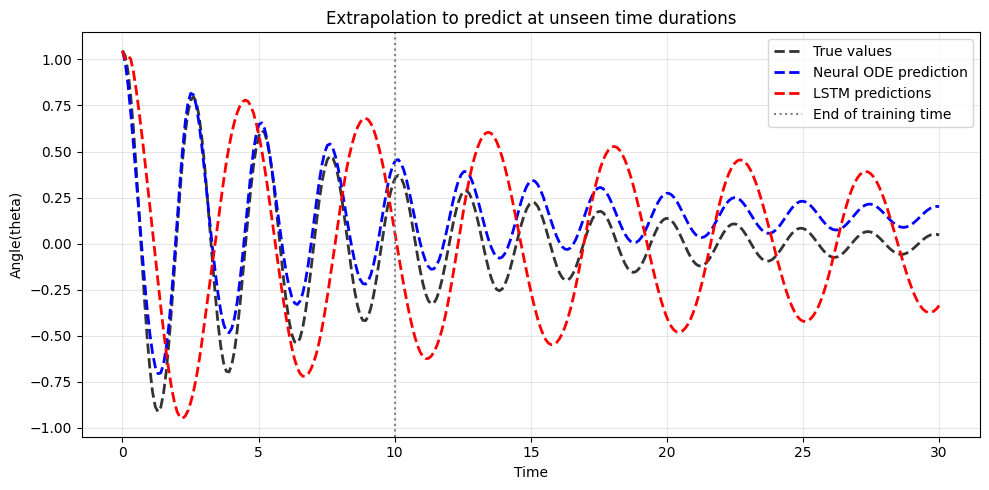

In [7]:
import matplotlib.pyplot as plt
import torch

test_L = 1.5
b_val, g_val = 0.2, 9.81
t_extrap_np = np.linspace(0, 30, 300)
t_extrap_tensor = torch.tensor(t_extrap_np, dtype=torch.float32)

true_trajectory_np = odeint(damp_pendulum, initial_state, t_extrap_np, args=(b_val, g_val, test_L))

y0_test_ode = torch.tensor([np.pi/3., 0., test_L], dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
  pred_ode_tensor = ode_int(neural_ode_func, y0_test_ode, t_extrap_tensor, method='rk4').permute(1, 0, 2)
  pred_ode_np = pred_ode_tensor.squeeze().numpy()

  current_seq = y0_test_ode.unsqueeze(0)

  for _ in range(len(t_extrap_np) - 1):
    next_step_pred = lstm_model(current_seq)[:, -1:, :]
    current_seq = torch.cat((current_seq, next_step_pred), dim=1)

  pred_lstm_np = current_seq.squeeze().numpy()

plt.figure(figsize=(10, 5))
plt.plot(t_extrap_np, true_trajectory_np[:, 0], "k--", label="True values", linewidth=2, alpha=0.8)
plt.plot(t_extrap_np, pred_ode_np[:, 0], "b--", label="Neural ODE prediction", linewidth=2)
plt.plot(t_extrap_np, pred_lstm_np[:, 0], "r--", label="LSTM predictions", linewidth=2)


plt.axvline(10, color="gray", linestyle=":", label="End of training time")
plt.title("Extrapolation to predict at unseen time durations")
plt.xlabel("Time")
plt.ylabel("Angle(theta)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




We can observe that the Neural ODE model is close to the actual solution plot. while, the loss of LSTM is shown to be very less at training, was surely overfitting. So, Neural ODE is shown to be better as per the implementation.

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

noise = 0.3
matrix = np.random.normal(0, noise, X_train_np.shape)
X_train_noise_np = X_train_np + matrix
X_train_noisy = torch.tensor(X_train_noise_np, dtype=torch.float32)

neural_ode_func = ODEFunc()
lstm_model = LSTMBase()

print("Retraining models on noisy data (0.3 noise level)...")

optimizer_ode = torch.optim.Adam(neural_ode_func.parameters(), lr=0.002)
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=0.002)
criterion = nn.MSELoss()

epochs = 1500
for epoch in range(epochs):
    optimizer_ode.zero_grad()
    y0_train = X_train_noisy[:, 0, :]
    pred_ode = ode_int(neural_ode_func, y0_train, t_tensor, method='rk4').permute(1, 0, 2)
    loss_ode = criterion(pred_ode[..., :2], X_train_noisy[..., :2])
    loss_ode.backward()
    optimizer_ode.step()

    optimizer_lstm.zero_grad()
    lstm_input = X_train_noisy[:, :-1, :]
    lstm_target = X_train_noisy[:, 1:, :]
    pred_lstm = lstm_model(lstm_input)
    loss_lstm = criterion(pred_lstm[..., :2], lstm_target[..., :2])
    loss_lstm.backward()
    optimizer_lstm.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | ODE Loss: {loss_ode.item():.4f} | LSTM Loss: {loss_lstm.item():.4f}")

print("Retraining complete")




Retraining models on noisy data (0.3 noise level)...
Epoch 000 | ODE Loss: 3.7005 | LSTM Loss: 1.1390
Epoch 100 | ODE Loss: 1.2000 | LSTM Loss: 0.1256
Epoch 200 | ODE Loss: 1.1856 | LSTM Loss: 0.1024
Epoch 300 | ODE Loss: 1.1688 | LSTM Loss: 0.0977
Epoch 400 | ODE Loss: 1.1354 | LSTM Loss: 0.0940
Epoch 500 | ODE Loss: 0.7213 | LSTM Loss: 0.0906
Epoch 600 | ODE Loss: 0.8140 | LSTM Loss: 0.0875
Epoch 700 | ODE Loss: 0.5188 | LSTM Loss: 0.0845
Epoch 800 | ODE Loss: 0.5994 | LSTM Loss: 0.0818
Epoch 900 | ODE Loss: 0.4739 | LSTM Loss: 0.0796
Epoch 1000 | ODE Loss: 1.0234 | LSTM Loss: 0.0786
Epoch 1100 | ODE Loss: 0.4614 | LSTM Loss: 0.0767
Epoch 1200 | ODE Loss: 0.4504 | LSTM Loss: 0.0755
Epoch 1300 | ODE Loss: 0.7077 | LSTM Loss: 0.0746
Epoch 1400 | ODE Loss: 0.8587 | LSTM Loss: 0.0737
Retraining complete!


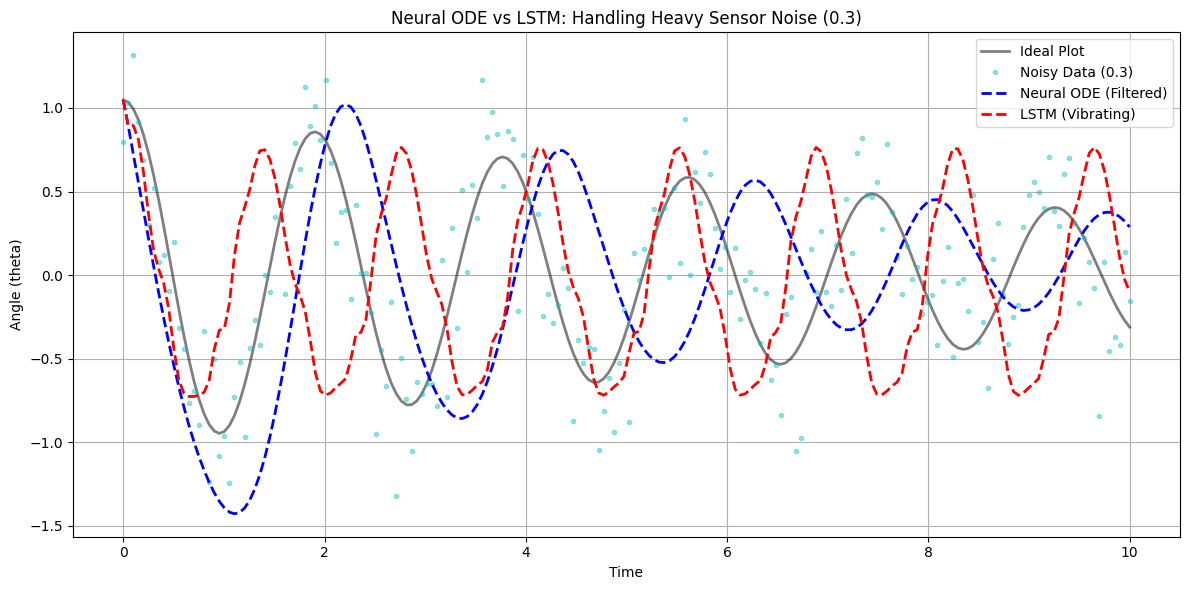

In [13]:
y0_clean = X_train[:, 0, :]
y0_clean_lstm = X_train[:, 0:1, :]

with torch.no_grad():
    pred_ode_noisy = ode_int(
        neural_ode_func,
        y0_clean,
        t_tensor,
        method='rk4'
    ).permute(1, 0, 2)

    current_seq = y0_clean_lstm

    for _ in range(len(t_list) - 1):
      next_step_pred = lstm_model(current_seq)[:, -1:, :]
      current_seq = torch.cat((current_seq, next_step_pred), dim=1)

    pred_lstm_noisy = current_seq

pred_ode_np = pred_ode_noisy[0].numpy()
pred_lstm_np = pred_lstm_noisy[0].numpy()

plt.figure(figsize=(12, 6))

plt.plot(t_list, X_train_np[0, :, 0], 'k-', label="Ideal Plot", linewidth=2, alpha=0.5)
plt.plot(t_list, X_train_noise_np[0, :, 0], 'c.', alpha=0.4, label="Noisy Data (0.3)")


plt.plot(t_list, pred_ode_np[:, 0], 'b--', label="Neural ODE (Filtered)", linewidth=2)
plt.plot(t_list, pred_lstm_np[:, 0], 'r--', label="LSTM (Vibrating)", linewidth=2)

plt.title("Neural ODE vs LSTM: Handling Heavy Sensor Noise (0.3)")
plt.xlabel("Time")
plt.ylabel("Angle (theta)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

As in the diagram, the LSTM is more less fitting the curve as the initial errors in the LSTMs get compounded over and over again. In such situations, the Neural ODE is helpful...